In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [3]:
df = pd.read_csv("week2dataset.csv")

In [4]:
#check dataset

df.head()

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9327 entries, 0 to 9326
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       9327 non-null   object 
 1   Order_ID          9327 non-null   object 
 2   Order_Date        9327 non-null   object 
 3   Region            9327 non-null   object 
 4   Category          9327 non-null   object 
 5   Product           9327 non-null   object 
 6   Quantity          9327 non-null   int64  
 7   Unit_Price        9327 non-null   float64
 8   Sales             9327 non-null   float64
 9   Profit            9327 non-null   float64
 10  Customer_Segment  9327 non-null   object 
 11  Customer_Type     9327 non-null   object 
 12  Age               9326 non-null   float64
 13  Gender            9326 non-null   object 
 14  Discount_Percent  9326 non-null   float64
dtypes: float64(5), int64(1), object(9)
memory usage: 1.1+ MB


,Quantity,Unit_Price,Sales,Profit,Age,Discount_Percent
count,9327.000000,9327.000000,9327.000000,9327.000000,9326.000000,9326.000000
mean,5.427898,498.274988,2703.533495,579.782991,43.996354,9.959790
std,2.873844,285.979423,2254.083332,553.785912,15.275872,7.090453
min,1.000000,10.050000,12.750000,1.540000,18.000000,0.000000
25%,3.000000,250.270000,842.260000,165.355000,31.000000,5.000000
50%,5.000000,498.360000,2063.670000,401.540000,44.000000,10.000000
75%,8.000000,740.645000,4055.585000,823.440000,57.000000,15.000000
max,10.000000,1000.000000,9998.200000,3334.420000,70.000000,20.000000


In [5]:
#convert target column into number
df["Customer_Type"] = df["Customer_Type"].map({
    "New":0,
    "Returning":1
})

In [6]:
#encode categorical column
encoder = LabelEncoder()

df["Region"] = encoder.fit_transform(df["Region"])
df["Category"] = encoder.fit_transform(df["Category"])
df["Product"] = encoder.fit_transform(df["Product"])
df["Customer_Segment"] = encoder.fit_transform(df["Customer_Segment"])
df["Gender"] = encoder.fit_transform(df["Gender"])

In [9]:
# select feature
X = df[[
    "Region",
    "Category",
    "Product",
    "Quantity",
    "Unit_Price",
    "Sales",
    "Profit",
    "Customer_Segment",
    "Age",
    "Gender",
    "Discount_Percent"
]]

y = df["Customer_Type"]

In [10]:
#split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [11]:
import numpy as np
#train logistic regression
lr = LogisticRegression(max_iter=5000) # Increased max_iter

# Identify rows with NaN values in X_train or y_train
nan_rows_X_train = X_train.isnull().any(axis=1)
nan_rows_y_train = y_train.isnull()

# Combine the boolean masks to find all rows that have NaN in either X_train or y_train
rows_to_drop_train = nan_rows_X_train | nan_rows_y_train

# Drop these rows from both X_train and y_train
X_train_cleaned = X_train[~rows_to_drop_train]
y_train_cleaned = y_train[~rows_to_drop_train]

# Also clean X_test and y_test similarly for prediction
nan_rows_X_test = X_test.isnull().any(axis=1)
nan_rows_y_test = y_test.isnull()
rows_to_drop_test = nan_rows_X_test | nan_rows_y_test
X_test_cleaned = X_test[~rows_to_drop_test]
y_test_cleaned = y_test[~rows_to_drop_test]

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train_cleaned)
X_test_scaled = scaler.transform(X_test_cleaned)

lr.fit(X_train_scaled, y_train_cleaned)

lr_pred = lr.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test_cleaned, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.4938337801608579


In [12]:
#train descision tree
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_cleaned, y_train_cleaned)

dt_pred = dt.predict(X_test_cleaned)

dt_accuracy = accuracy_score(y_test_cleaned, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.5072386058981233


In [13]:
#train random forest
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train_cleaned, y_train_cleaned)

rf_pred = rf.predict(X_test_cleaned)

rf_accuracy = accuracy_score(y_test_cleaned, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.4938337801608579


In [14]:
#compare models
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

print(comparison)

                 Model  Accuracy
0  Logistic Regression  0.493834
1        Decision Tree  0.507239
2        Random Forest  0.493834


In [18]:
#best model
best = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

print(best)

                 Model  Accuracy
1        Decision Tree  0.507239
0  Logistic Regression  0.493834
2        Random Forest  0.493834


In [20]:
import numpy as np
#classification report
print(classification_report(y_test_cleaned, rf_pred))

              precision    recall  f1-score   support

           0       0.51      0.46      0.48       956
           1       0.48      0.53      0.51       909

    accuracy                           0.49      1865
   macro avg       0.49      0.49      0.49      1865
weighted avg       0.50      0.49      0.49      1865



In [22]:
#confusion matrix
cm = confusion_matrix(y_test_cleaned, rf_pred)

print(cm)

[[438 518]
 [426 483]]


In [23]:
#feature importance
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

             Feature  Importance
6             Profit    0.159388
4         Unit_Price    0.152108
5              Sales    0.150678
2            Product    0.136511
8                Age    0.125392
3           Quantity    0.061149
0             Region    0.054481
1           Category    0.053676
10  Discount_Percent    0.051670
7   Customer_Segment    0.033440
9             Gender    0.021507


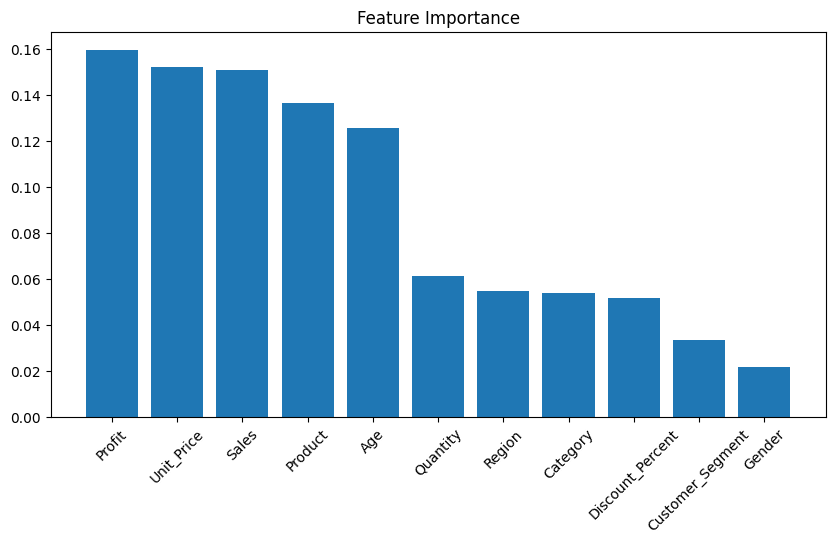

In [24]:
#plot feature importance
plt.figure(figsize=(10,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.show()

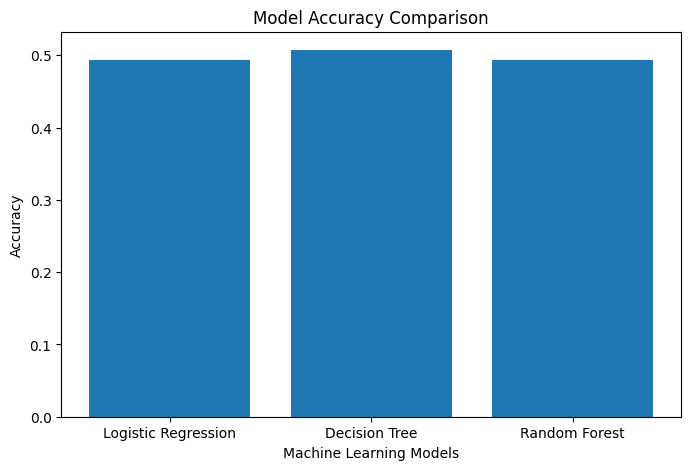

In [25]:
#visualize model accuracy
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracy = [lr_accuracy, dt_accuracy, rf_accuracy]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")
plt.show()

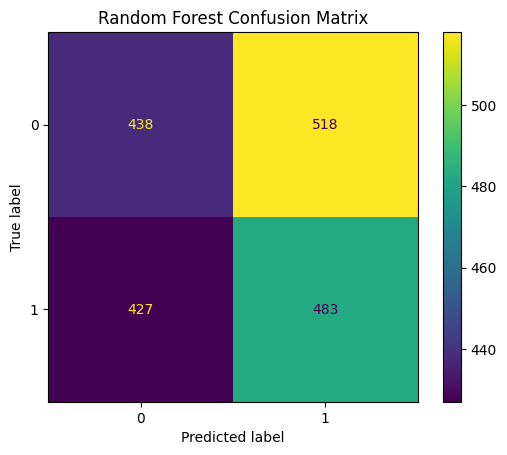

In [26]:
#plot the confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Random Forest Confusion Matrix")
plt.show()

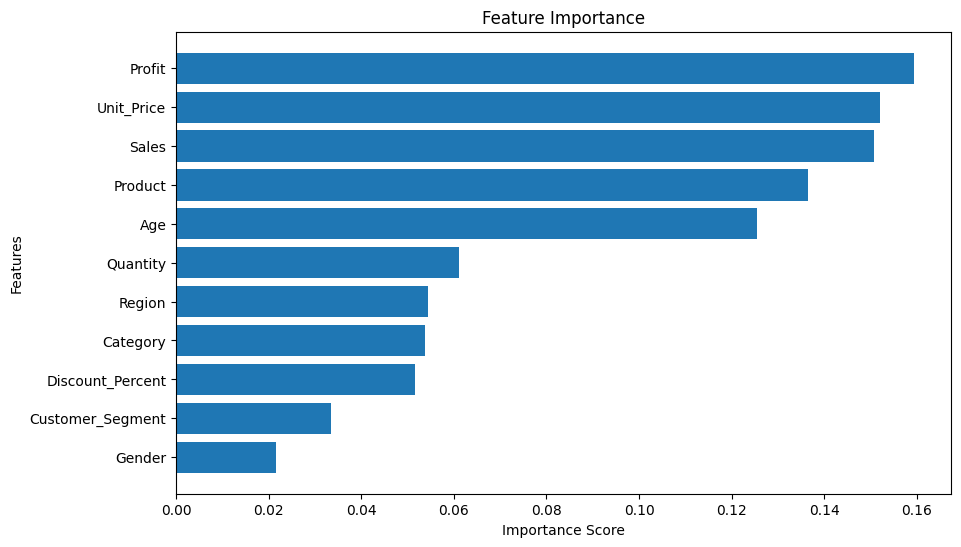

In [27]:
#interpret feature importance
importance = importance.sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10,6))
plt.barh(importance["Feature"], importance["Importance"])
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [28]:
#predict for new costumer
new_customer = pd.DataFrame({
    "Region": [1],
    "Category": [2],
    "Product": [15],
    "Quantity": [3],
    "Unit_Price": [500],
    "Sales": [1500],
    "Profit": [250],
    "Customer_Segment": [1],
    "Age": [30],
    "Gender": [1],
    "Discount_Percent": [10]
})

prediction = rf.predict(new_customer)

if prediction[0] == 1:
    print("Prediction: Returning Customer")
else:
    print("Prediction: New Customer")

Prediction: Returning Customer


In [33]:
import joblib

joblib.dump(rf, "Customer_Prediction_Model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [36]:
import joblib

# Using the 'rf' model and increasing compression to level 9
joblib.dump(rf, "Customer_Prediction_Model.pkl", compress=9)

['Customer_Prediction_Model.pkl']

In [37]:
from google.colab import files

files.download("Customer_Prediction_Model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>